In [1]:
# marllib/envs/custom/diffdrive_env.py

from custom_envs.diff_driven.gym_env.centered_paralelenv.env import DiffDriveEnv

def env_creator(args=None):
    return DiffDriveEnv()

env = {
    "name": "diffdrive_custom",
    "env_creator": env_creator,
    "env_type": "mpe",  # This is needed to support PettingZoo ParallelEnv
}


In [7]:
import torch
num_landmarks=6
num_samples = num_landmarks * 3
base = 100 - num_samples  # get last n*3 steps
# Randomly sample unique timesteps from the last n*3
rand_list = torch.randperm(num_samples) + base  # shape: [num_samples]

             # Store last positions into 3 groups of landmark sets
last_positions_list = [torch.zeros((num_landmarks, 2))
                                       for _ in range(3)]

                # For each of the 3 sets
for k in range(3):
    for l in range(num_landmarks):
                        idx = rand_list[k * num_landmarks + l].item()
                        # Pick agent l's position at timestep idx
                        # pos_np = episode_trajectory[idx][l]
                        last_positions_list[k][l, :] = torch.tensor( [idx, l])
last_positions_list

[tensor([[83.,  0.],
         [91.,  1.],
         [92.,  2.],
         [99.,  3.],
         [93.,  4.],
         [90.,  5.]]),
 tensor([[96.,  0.],
         [88.,  1.],
         [89.,  2.],
         [86.,  3.],
         [87.,  4.],
         [82.,  5.]]),
 tensor([[98.,  0.],
         [94.,  1.],
         [85.,  2.],
         [84.,  3.],
         [97.,  4.],
         [95.,  5.]])]

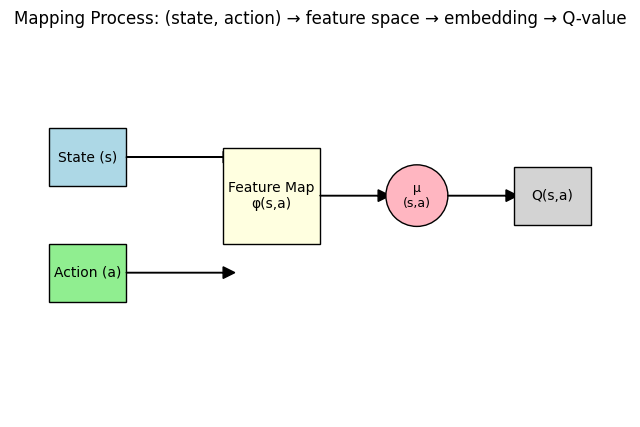

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure
fig, ax = plt.subplots(figsize=(8, 5))

# Boxes for states and actions
ax.add_patch(patches.Rectangle((0.1, 0.6), 0.2, 0.15, fill=True, edgecolor="black", facecolor="lightblue"))
ax.text(0.2, 0.675, "State (s)", ha="center", va="center", fontsize=10)

ax.add_patch(patches.Rectangle((0.1, 0.3), 0.2, 0.15, fill=True, edgecolor="black", facecolor="lightgreen"))
ax.text(0.2, 0.375, "Action (a)", ha="center", va="center", fontsize=10)

# Arrow to feature space
ax.arrow(0.3, 0.675, 0.25, 0, head_width=0.03, head_length=0.03, fc="black", ec="black")
ax.arrow(0.3, 0.375, 0.25, 0, head_width=0.03, head_length=0.03, fc="black", ec="black")

# Feature space box
ax.add_patch(patches.Rectangle((0.55, 0.45), 0.25, 0.25, fill=True, edgecolor="black", facecolor="lightyellow"))
ax.text(0.675, 0.575, "Feature Map\nφ(s,a)", ha="center", va="center", fontsize=10)

# Arrow to embedding
ax.arrow(0.8, 0.575, 0.15, 0, head_width=0.03, head_length=0.03, fc="black", ec="black")

# Embedding circle
circle = patches.Circle((1.05, 0.575), 0.08, fill=True, edgecolor="black", facecolor="lightpink")
ax.add_patch(circle)
ax.text(1.05, 0.575, "μ\n(s,a)", ha="center", va="center", fontsize=9)

# Arrow to Q-value
ax.arrow(1.13, 0.575, 0.15, 0, head_width=0.03, head_length=0.03, fc="black", ec="black")

# Q-value box
ax.add_patch(patches.Rectangle((1.3, 0.5), 0.2, 0.15, fill=True, edgecolor="black", facecolor="lightgray"))
ax.text(1.4, 0.575, "Q(s,a)", ha="center", va="center", fontsize=10)

# Style
ax.set_xlim(0, 1.6)
ax.set_ylim(0, 1)
ax.axis("off")

plt.title("Mapping Process: (state, action) → feature space → embedding → Q-value", fontsize=12)
plt.show()
